In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

In [ ]:
path = r"C:\Users\tiffany.ona\Documents\working_memory\data"

# --- Load mouse data ---
filename = r"\2AFC_drug_experiments_df.csv"
df = pd.read_csv(path+filename, index_col=0)

# --- Load synthetic data ---
filename = r"\2AFC_drug_experiments_synthetic.csv"
df_synthetic = pd.read_csv(path + r"\2AFC_drug_experiments_synthetic.csv", index_col=0)


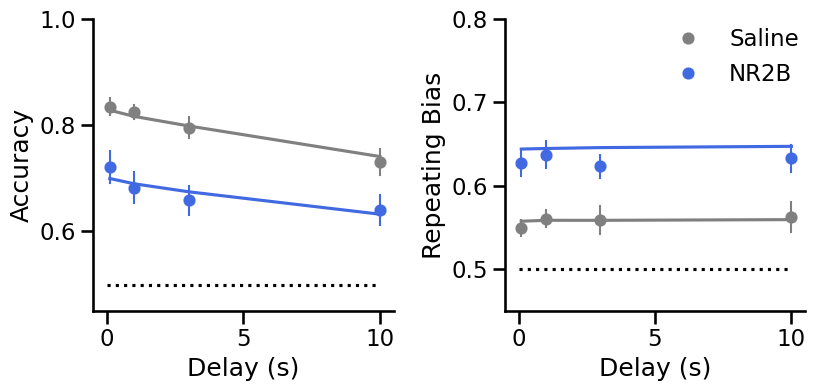

In [78]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 4.25), sharey=False)


# --- Aggregate ---
df_accuracy = (
    df.groupby(['subject', 'drug', 'delays'])['hit']
    .mean()
    .reset_index(name='accuracy')
)
df_accuracy_syn = (
    df_synthetic.groupby(['subject', 'drug', 'delays'])['hit']
    .mean()
    .reset_index(name='accuracy')
)

def compute_bias(d):
    left        = d[d['repeat_choice_side'] == 1].groupby(['drug', 'subject', 'delays'])['hit'].count()
    right       = d[d['repeat_choice_side'] == 2].groupby(['drug', 'subject', 'delays'])['hit'].count()
    denom_left  = d[d['choices'] == -1].groupby(['drug', 'subject', 'delays'])['hit'].count()
    denom_right = d[d['choices'] ==  1].groupby(['drug', 'subject', 'delays'])['hit'].count()
    return (0.5 * left / denom_left + 0.5 * right / denom_right).reset_index(name='prob_repeat')

df_bias     = compute_bias(df)
df_bias_syn = compute_bias(df_synthetic)

# --- Style dicts ---
drug_styles = {
    'Saline': {'color': 'grey',       'label': 'Saline'},
    'NR2B':   {'color': 'royalblue',  'label': 'NR2B'},
}

plot_kwargs     = dict(markeredgewidth=0.2, marker='o', err_style='bars', linewidth=0,
                       err_kws={'capsize': 0, 'elinewidth': 1.5},
                       errorbar='se')
plot_kwargs_syn = dict(markeredgewidth=0.2, marker='', err_style=None)


for drug, style in drug_styles.items():
    # --- Plot 1: Accuracy ---
    sns.lineplot(x='delays', y='accuracy',
                 data=df_accuracy[df_accuracy['drug'] == drug],
                 ax=ax[0], **plot_kwargs, **style)
    sns.lineplot(x='delays', y='accuracy',
                 data=df_accuracy_syn[df_accuracy_syn['drug'] == drug],
                 ax=ax[0], **plot_kwargs_syn, **{k: v for k, v in drug_styles[drug].items() if k != 'label'})

    # --- Plot 2: Repeating Bias ---
    sns.lineplot(x='delays', y='prob_repeat',
                data=df_bias[df_bias['drug'] == drug],
                ax=ax[1], **plot_kwargs, **drug_styles[drug])

    sns.lineplot(x='delays', y='prob_repeat',
                data=df_bias_syn[df_bias_syn['drug'] == drug],
                ax=ax[1], **plot_kwargs_syn, **{k: v for k, v in drug_styles[drug].items() if k != 'label'})

# --- Shared formatting ---
CHANCE  = 0.5
X_RANGE = (0, 10)

for a in ax:
    a.hlines(y=CHANCE, xmin=X_RANGE[0], xmax=X_RANGE[1], linestyle=':', color='black')
    a.set_xlabel('Delay (s)')
    a.tick_params(axis='y', colors='black')

ax[0].set(ylabel='Accuracy',       ylim=(0.45, 0.9), yticks=[0.6, 0.8, 1.0])
ax[1].set(ylabel='Repeating Bias', ylim=(0.45, 0.8), yticks=[0.5, 0.6, 0.7, 0.8])
ax[1].xaxis.label.set_color('black')

plt.tight_layout()
sns.despine()
ax[1].legend(bbox_to_anchor=(1.01, 1), borderaxespad=0).get_frame().set_linewidth(0.0)
ax[0].legend().remove()